In [1]:
# Installing necessary libraries
!pip install tensorflow numpy pandas matplotlib seaborn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [3]:
# Uploading the dataset
file_path = "/content/credit_card_customers.csv"
raw_data = pd.read_csv(file_path)

In [4]:
# Basic preprocessing
print("Dataset Shape:", raw_data.shape)
raw_data.dropna(inplace=True)  # Handling missing values
raw_data = raw_data.select_dtypes(include=[np.number])  # Selecting numeric columns
raw_data = raw_data.iloc[:, 1:]  # Removing non-numeric or unnecessary columns


Dataset Shape: (8950, 18)


In [5]:
# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(raw_data)

In [6]:
# Defining the autoencoder architecture
input_dim = data_scaled.shape[1]
encoding_dim = 8  # Dimension of the latent space

In [7]:
# Encoder
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation="relu")(input_layer)
encoder = Dense(encoding_dim, activation="relu")(encoder)

# Decoder
decoder = Dense(16, activation="relu")(encoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)

In [8]:
# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile the model
autoencoder.compile(optimizer="adam", loss="mse")

In [9]:
# Train the autoencoder
history = autoencoder.fit(data_scaled, data_scaled, epochs=50, batch_size=32, shuffle=True, validation_split=0.2)


Epoch 1/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 1.1716 - val_loss: 0.7005
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8118 - val_loss: 0.6130
Epoch 3/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8240 - val_loss: 0.5893
Epoch 4/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7888 - val_loss: 0.5738
Epoch 5/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6461 - val_loss: 0.5661
Epoch 6/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7158 - val_loss: 0.5593
Epoch 7/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6775 - val_loss: 0.5558
Epoch 8/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7686 - val_loss: 0.5511
Epoch 9/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7115 - val_loss: 0.5478
Epoch 10/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7127 - val_loss: 0.5452
Epoch 11/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6431 - val_loss: 0.5441
Epoch 12/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/ste

In [10]:
# Extract the encoder model
encoder_model = Model(inputs=input_layer, outputs=encoder)
data_encoded = encoder_model.predict(data_scaled)

270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [22]:
# Find silhouette scores for clusters ranging from 2 to 20
silhouette_scores = []
clusters_range = range(2, 20)

In [23]:
for n_clusters in clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(data_encoded)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(data_encoded, labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Number of Clusters: {n_clusters}, Silhouette Score: {silhouette_avg:.4f}")


Number of Clusters: 2, Silhouette Score: 0.3092
Number of Clusters: 3, Silhouette Score: 0.2024
Number of Clusters: 4, Silhouette Score: 0.2271
Number of Clusters: 5, Silhouette Score: 0.2317
Number of Clusters: 6, Silhouette Score: 0.2429
Number of Clusters: 7, Silhouette Score: 0.2345
Number of Clusters: 8, Silhouette Score: 0.2380
Number of Clusters: 9, Silhouette Score: 0.2295
Number of Clusters: 10, Silhouette Score: 0.2187
Number of Clusters: 11, Silhouette Score: 0.1864
Number of Clusters: 12, Silhouette Score: 0.1800
Number of Clusters: 13, Silhouette Score: 0.1919
Number of Clusters: 14, Silhouette Score: 0.1890
Number of Clusters: 15, Silhouette Score: 0.1839
Number of Clusters: 16, Silhouette Score: 0.1841
Number of Clusters: 17, Silhouette Score: 0.1834
Number of Clusters: 18, Silhouette Score: 0.1836
Number of Clusters: 19, Silhouette Score: 0.1849


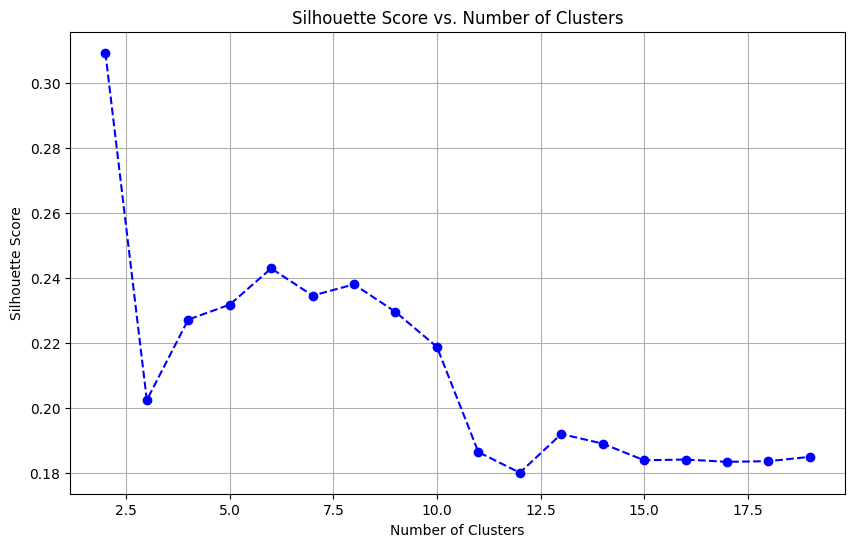

In [24]:
# Plot the silhouette score graph
plt.figure(figsize=(10, 6))
plt.plot(clusters_range, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

In [25]:
# Apply K-Means clustering on the encoded data
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_encoded)
labels = kmeans.labels_

In [26]:
# Evaluate clustering
silhouette_avg = silhouette_score(data_encoded, labels)
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.20236655


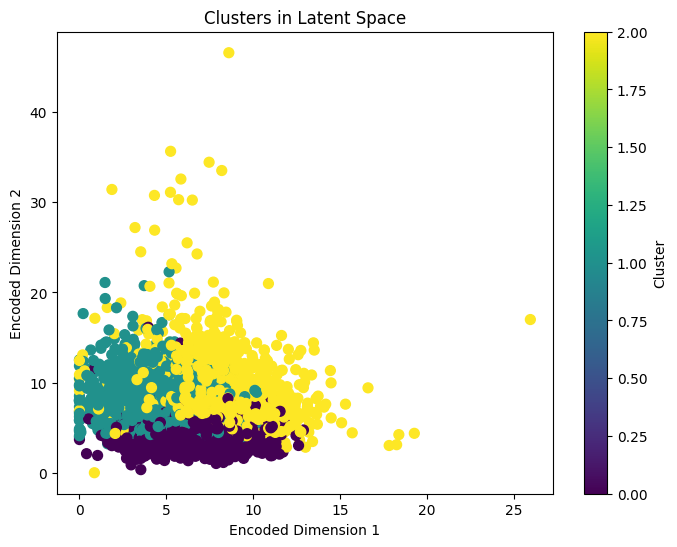

In [27]:
# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(data_encoded[:, 0], data_encoded[:, 1], c=labels, cmap="viridis", s=50)
plt.colorbar(label="Cluster")
plt.title("Clusters in Latent Space")
plt.xlabel("Encoded Dimension 1")
plt.ylabel("Encoded Dimension 2")
plt.show()